# Candidate Problem Exploration: Delivery Performance

**Dual framing, one problem** (per supervisor's Example 4):

- **Question:** How can delivery performance be predicted and acted on?
- **Framing A (regression):** predict delivery lead time in days
- **Framing B (classification):** using the same lead-time target, classify orders as late vs on-time against the estimated delivery date
- **Why it works:** one underlying problem, two complementary outputs — satisfies the classification + regression requirement without a second, unrelated problem
- **Stakeholder:** Operations team — wants both a precise delay estimate (regression) and a simple at-risk flag (classification)

## At a glance

**What's in here.** One consolidated order-level table built from the 9 Olist CSVs (orders + items + products + customers + sellers + geolocation), cleaned (delivered orders only, valid delivery date, known seller↔buyer distance, delivery time trimmed to 0–60 days, missing weights imputed) → **95,709 orders**. One stratified train/test split and one feature pipeline feed **two framings of the same problem**: regression = delivery lead time in days; classification = late vs on-time against Olist's own estimate (`is_late`, ~7.8% positive).

**Methods tried.**
- *Regression:* Linear Regression, Random Forest, Gradient Boosting.
- *Classification:* Logistic Regression, Random Forest, Gradient Boosting / HistGradientBoosting, all with balanced class weights.
- *Imbalance handling:* decision-threshold tuning on out-of-fold PR curves (max-F1 and recall≥0.70 operating points) and resampling (SMOTE, random undersampling) inside `imblearn` pipelines.

**Scores achieved (held-out test).**

| Framing | Best model | Key metrics |
|---|---|---|
| Regression | Random Forest | MAE ≈ 4.6 days · RMSE ≈ 6.7 · R² ≈ 0.37 |
| Classification | HistGB (balanced) @ threshold ≈ 0.65 | ROC-AUC ≈ 0.75 · late-class F1 ≈ 0.30, recall 0.41, precision 0.24 |

Threshold tuning roughly doubled late-class F1 vs the default 0.50 cut-off (≈0.15 → 0.30) and a lower cut-off flags more orders (recall ↑, precision ↓), a higher one flags fewer but surer ones (recall ↓, precision ↑); e.g. recall 0.70 is reachable at ≈0.14 precision. **Resampling added nothing** over class weights.

**Limitations.**
- Scores are **not deployment-grade**: regression explains only ~37% of variance (±4.6 days typical error); the classifier catches under half of late orders at 1-in-4 precision.
- Root cause is the **data, not the tuning** — Olist records *outcomes* (dates, prices, scores) but almost none of the *determinants* of delivery time: carrier, dispatch/warehouse events, route, capacity, weather, seller processing lag. The available features (distance, state, category, size) cap ROC-AUC near 0.75.
- **The classification target is questionable.** `is_late` is defined against Olist's own delivery estimate — a product lever, not ground truth. The late rate could be driven to zero just by padding every estimate (the estimate is already slack: the median order lands ~10+ days early), so the model is partly predicting the sign of original system's forecast error. A target that can't be gamed this way.
- Not yet tried: feature engineering — e.g. how tight the delivery estimate is vs. what's typical for the route, fulfilment-stage lags, seller/route history. Candidates are listed under "Notes for Phase 2"; none are confirmed to help.
- Random split only (no temporal hold-out); data spans Sep 2016 – Oct 2018; ~0.5% of items dropped for missing geolocation.

## 0. Setup & Data Loading

In [11]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [12]:
DATA_DIR = 'IT5006_Project-Data/Olist_CSV'

def load_olist_data(data_dir):
    tables = {
        'orders': 'olist_orders_dataset.csv',
        'order_items': 'olist_order_items_dataset.csv',
        'customers': 'olist_customers_dataset.csv',
        'products': 'olist_products_dataset.csv',
        'sellers': 'olist_sellers_dataset.csv',
        'geolocation': 'olist_geolocation_dataset.csv',
        'category_translation': 'product_category_name_translation.csv'
    }
    date_cols = {
        'orders': ['order_purchase_timestamp', 'order_approved_at',
                   'order_delivered_carrier_date', 'order_delivered_customer_date',
                   'order_estimated_delivery_date'],
        'order_items': ['shipping_limit_date']
    }
    data = {}
    for name, filename in tables.items():
        filepath = os.path.join(data_dir, filename)
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows x {data[name].shape[1]} cols")
    return data

olist = load_olist_data(DATA_DIR)

Loaded orders: 99,441 rows x 8 cols
Loaded order_items: 112,650 rows x 7 cols
Loaded customers: 99,441 rows x 5 cols
Loaded products: 32,951 rows x 9 cols
Loaded sellers: 3,095 rows x 4 cols
Loaded geolocation: 1,000,163 rows x 5 cols
Loaded category_translation: 71 rows x 2 cols


## 1. Build the Consolidated Dataset

In [13]:
products = olist['products'].merge(olist['category_translation'], on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna('Unknown')

# clean: fill missing product_weight_g (2 rows) -> category median, then global median as fallback
products['product_weight_g'] = products.groupby('product_category_name_english')['product_weight_g'].transform(
    lambda s: s.fillna(s.median())
)
products['product_weight_g'] = products['product_weight_g'].fillna(products['product_weight_g'].median())

df = olist['order_items'].copy()
df = df.merge(products[['product_id', 'product_category_name_english', 'product_weight_g']], on='product_id', how='left')
df = df.merge(
    olist['orders'][['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
                     'order_delivered_customer_date', 'order_estimated_delivery_date']],
    on='order_id', how='left'
)
df = df.merge(olist['customers'][['customer_id', 'customer_state', 'customer_zip_code_prefix']], on='customer_id', how='left')
df = df.merge(olist['sellers'][['seller_id', 'seller_state', 'seller_zip_code_prefix']], on='seller_id', how='left')

df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()
df['month'] = df['order_purchase_timestamp'].dt.month
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
# classification target: 1 = late vs the estimate. Only defined for delivered orders (no delivery date -> NaN)
df['is_late'] = np.where(
    df['order_delivered_customer_date'].notna(),
    (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype(float),
    np.nan
)

print(df.shape)
df.head()

(112650, 22)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,product_weight_g,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_zip_code_prefix,seller_state,seller_zip_code_prefix,day_of_week,month,delivery_days,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,650.00,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,RJ,28013,SP,27277,Wednesday,9,7.00,0.00
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,30000.00,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,SP,15775,SP,3471,Wednesday,4,16.00,0.00
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,3050.00,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,MG,35661,MG,37564,Sunday,1,7.00,0.00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,200.00,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,SP,12952,SP,14403,Wednesday,8,6.00,0.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,3750.00,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,SP,13226,PR,87900,Saturday,2,25.00,0.00


### 1.1 Seller-buyer distance

In [14]:
geo = olist['geolocation']

geo_agg = geo.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
).reset_index()

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df = df.merge(geo_agg.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
                                       'lat': 'customer_lat', 'lng': 'customer_lng'}),
              on='customer_zip_code_prefix', how='left')
df = df.merge(geo_agg.rename(columns={'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
                                       'lat': 'seller_lat', 'lng': 'seller_lng'}),
              on='seller_zip_code_prefix', how='left')

df['distance_km'] = haversine(df['customer_lat'], df['customer_lng'], df['seller_lat'], df['seller_lng'])
print('distance coverage:', df['distance_km'].notna().mean().round(3))

distance coverage: 0.995


## 2. Order-Level Feature Table

Delivery outcome is one value per **order**, not per item, so we aggregate `df` up to order level. This single table feeds both framings below.

**Cleaning applied here:**
- keep only `delivered` orders that have an actual delivery date (8 delivered orders have none)
- require a known seller↔buyer `distance_km` (~0.5% of items lack geolocation)
- drop delivery-time outliers outside `0–60` days (negative = data error; long tail ≈ 0.3%)
- missing `product_weight_g` was already filled upstream (category median → global median)
- residual NaNs are also imputed inside the model pipeline as a safety net

In [15]:
order_level = df.groupby('order_id').agg(
    n_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    avg_weight=('product_weight_g', 'mean'),
    n_sellers=('seller_id', 'nunique'),
    category=('product_category_name_english', lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown'),
    customer_state=('customer_state', 'first'),
    seller_state=('seller_state', 'first'),
    distance_km=('distance_km', 'mean'),
    day_of_week=('day_of_week', 'first'),
    month=('month', 'first'),
    order_status=('order_status', 'first'),
    delivery_days=('delivery_days', 'first'),
    is_late=('is_late', 'first'),
).reset_index()

n0 = len(order_level)

# 1. keep only delivered orders with a usable target and known distance
model_df = order_level[order_level['order_status'] == 'delivered'].dropna(
    subset=['delivery_days', 'is_late', 'distance_km']
).copy()
n1 = len(model_df)

# 2. drop delivery-time outliers: negative (data error) or > 60 days (extreme tail, ~0.3%)
model_df = model_df[model_df['delivery_days'].between(0, 60)]
n2 = len(model_df)

model_df['is_late'] = model_df['is_late'].astype(int)

print(f"order_level rows           : {n0:,}")
print(f"after status/NA filter     : {n1:,}  (-{n0 - n1:,})")
print(f"after outlier trim (0-60d) : {n2:,}  (-{n1 - n2:,})")
print(f"late rate                  : {model_df['is_late'].mean():.3f}")
print(f"remaining NaNs in features : {model_df[['n_items','total_price','total_freight','avg_weight','n_sellers','distance_km']].isna().sum().sum()}")
model_df.head()

order_level rows           : 98,666
after status/NA filter     : 95,994  (-2,672)
after outlier trim (0-60d) : 95,709  (-285)
late rate                  : 0.078
remaining NaNs in features : 0


,order_id,n_items,total_price,total_freight,avg_weight,n_sellers,category,customer_state,seller_state,distance_km,day_of_week,month,order_status,delivery_days,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,650.00,1,cool_stuff,RJ,SP,301.50,Wednesday,9,delivered,7.00,0
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,30000.00,1,pet_shop,SP,SP,585.56,Wednesday,4,delivered,16.00,0
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,3050.00,1,furniture_decor,MG,MG,312.34,Sunday,1,delivered,7.00,0
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,200.00,1,perfumery,SP,SP,293.17,Wednesday,8,delivered,6.00,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,3750.00,1,garden_tools,SP,PR,646.16,Saturday,2,delivered,25.00,0


## 3. Features, Split, Preprocessing

One split, reused for both framings. Stratified on `is_late` to keep the (imbalanced) class ratio consistent across train/test.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_cols = ['n_items', 'total_price', 'total_freight', 'avg_weight', 'n_sellers', 'distance_km']
cat_cols = ['category', 'customer_state', 'seller_state', 'day_of_week', 'month']

X = model_df[num_cols + cat_cols]
y_class = model_df['is_late']
y_reg = model_df['delivery_days']

X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

# imputers guard against any residual NaN so the linear models don't choke
num_pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
cat_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                     ('ohe', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

---

## Framing B (Classification): Late vs On-Time

Positive class (`1`) = late. Class weights balanced to account for late orders being the minority.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

clf_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

clf_results = {}
for name, model in clf_models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_class_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    report = classification_report(y_class_test, pred, output_dict=True)
    auc = roc_auc_score(y_class_test, proba)
    clf_results[name] = {'F1 (late)': report['1']['f1-score'], 'Recall (late)': report['1']['recall'], 'ROC-AUC': auc}
    print(name)
    print(classification_report(y_class_test, pred))
    print('ROC-AUC:', round(auc, 3), '\n')

Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.65      0.78     17643
           1       0.14      0.66      0.23      1499

    accuracy                           0.65     19142
   macro avg       0.55      0.65      0.50     19142
weighted avg       0.89      0.65      0.73     19142

ROC-AUC: 0.712 

Random Forest
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     17643
           1       0.42      0.04      0.08      1499

    accuracy                           0.92     19142
   macro avg       0.67      0.52      0.52     19142
weighted avg       0.89      0.92      0.89     19142

ROC-AUC: 0.733 

Gradient Boosting
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     17643
           1       0.27      0.00      0.00      1499

    accuracy                           0.92     19142
   macro avg       0.60      0.50      0.4

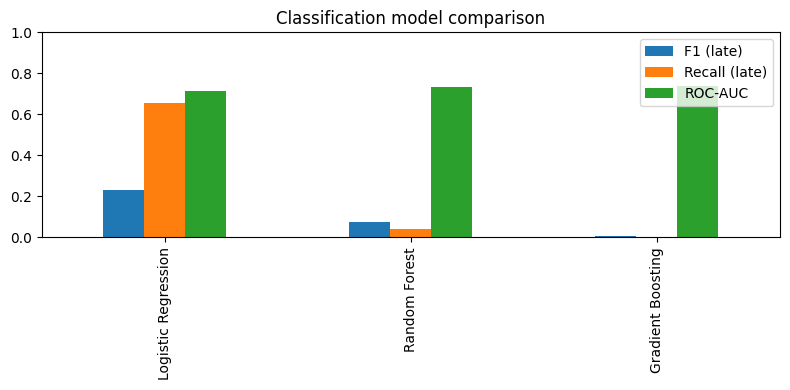

In [18]:
pd.DataFrame(clf_results).T.plot(kind='bar', figsize=(8, 4), title='Classification model comparison')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

---

## Framing B — Improving Late-Order Recall

The baseline hardly flags late orders (recall 0.04–0.66, F1 ≤ 0.23): only **7.8%** of orders are late and every model defaults to a 0.50 probability cut-off. Two levers, evaluated without leakage — threshold and any resampling are chosen on **out-of-fold training predictions**, then the config is scored **once** on the untouched test set:

1. **Threshold tuning** — keep the model, move the cut-off.
2. **Resampling** — SMOTE / random undersampling on training folds only.

In [19]:
%pip install -q imbalanced-learn

from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (precision_recall_curve, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# HistGradientBoosting needs a dense matrix -> dense one-hot for this whole section
prep = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
])

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
CONFIGS = {}   # label -> {proba_tr (out-of-fold, train), proba_te (test)}

def _best_threshold(y_true, proba, mode='f1', target_recall=0.70):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    prec, rec = prec[:-1], rec[:-1]                  # align with thr
    if mode == 'f1':
        f1 = 2 * prec * rec / (prec + rec + 1e-9)
        return float(thr[f1.argmax()])
    ok = rec >= target_recall
    return float(thr[ok][-1]) if ok.any() else 0.5  # loosest cut-off still hitting the recall target

def register(label, pipe):
    """OOF P(late) on train (for threshold picking) + P(late) on test (scored once)."""
    CONFIGS[label] = {'proba_tr': cross_val_predict(
        pipe, X_train, y_class_train, cv=CV, method='predict_proba')[:, 1]}
    pipe.fit(X_train, y_class_train)
    CONFIGS[label]['proba_te'] = pipe.predict_proba(X_test)[:, 1]

def score_at(label, thr, tag=''):
    c = CONFIGS[label]
    pred = (c['proba_te'] >= thr).astype(int)
    return {
        'config': f'{label} {tag}'.strip(), 'thr': round(float(thr), 3),
        'precision_late': round(precision_score(y_class_test, pred, zero_division=0), 3),
        'recall_late':    round(recall_score(y_class_test, pred, zero_division=0), 3),
        'f1_late':        round(f1_score(y_class_test, pred, zero_division=0), 3),
        'roc_auc':        round(roc_auc_score(y_class_test, c['proba_te']), 3),
    }

print('late rate  train: %.3f   test: %.3f' % (y_class_train.mean(), y_class_test.mean()))

Note: you may need to restart the kernel to use updated packages.
late rate  train: 0.078   test: 0.078


### 1. Threshold tuning

Pick the cut-off from the out-of-fold precision–recall curve: one that maximises F1 on the late class, and one that holds recall ≥ 0.70. Same fitted models as the baseline — only the decision boundary moves.

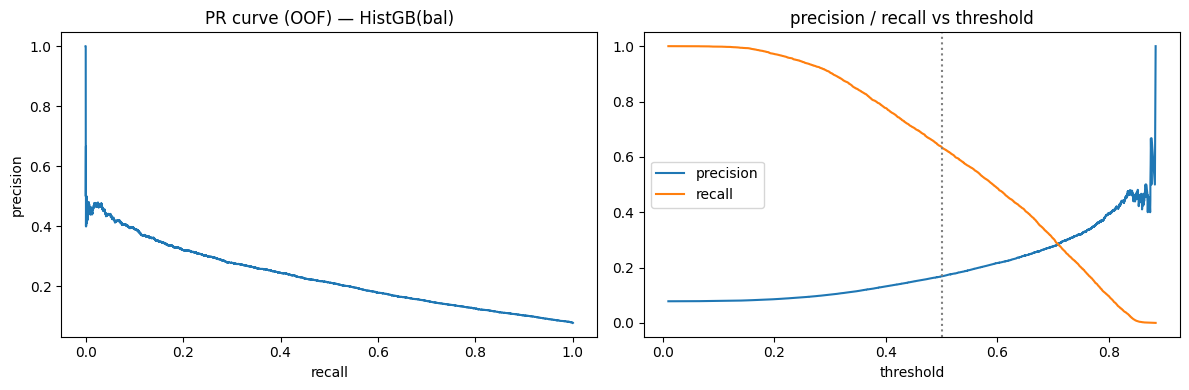

,config,thr,precision_late,recall_late,f1_late,roc_auc
0,LogReg(bal) @0.50,0.50,0.14,0.66,0.23,0.71
1,LogReg(bal) @maxF1,0.66,0.20,0.32,0.25,0.71
2,LogReg(bal) @rec>=.70,0.47,0.13,0.70,0.22,0.71
3,RF(bal) @0.50,0.50,0.42,0.04,0.07,0.74
4,RF(bal) @maxF1,0.17,0.24,0.39,0.30,0.74
5,RF(bal) @rec>=.70,0.07,0.14,0.71,0.24,0.74
6,HistGB(bal) @0.50,0.50,0.17,0.63,0.27,0.75
7,HistGB(bal) @maxF1,0.65,0.24,0.41,0.30,0.75
8,HistGB(bal) @rec>=.70,0.45,0.16,0.70,0.26,0.75


In [20]:
# --- 1. Threshold tuning: keep the model, move the decision cut-off off 0.50 ---
for name, model in {
    'LogReg(bal)': LogisticRegression(class_weight='balanced', max_iter=1000),
    'RF(bal)':     RandomForestClassifier(class_weight='balanced', n_estimators=150,
                                          n_jobs=-1, random_state=42),
    'HistGB(bal)': HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
}.items():
    register(name, Pipeline([('prep', prep), ('m', model)]))

rows = []
for name in ['LogReg(bal)', 'RF(bal)', 'HistGB(bal)']:
    p_tr = CONFIGS[name]['proba_tr']
    t_f1  = _best_threshold(y_class_train, p_tr, 'f1')
    t_rec = _best_threshold(y_class_train, p_tr, 'recall', 0.70)
    rows += [score_at(name, 0.50, '@0.50'),
             score_at(name, t_f1,  '@maxF1'),
             score_at(name, t_rec, '@rec>=.70')]
thr_df = pd.DataFrame(rows)

best = max(['LogReg(bal)', 'RF(bal)', 'HistGB(bal)'],
           key=lambda n: roc_auc_score(y_class_train, CONFIGS[n]['proba_tr']))
prec, rec, thr = precision_recall_curve(y_class_train, CONFIGS[best]['proba_tr'])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(rec, prec); ax[0].set(xlabel='recall', ylabel='precision', title=f'PR curve (OOF) — {best}')
ax[1].plot(thr, prec[:-1], label='precision'); ax[1].plot(thr, rec[:-1], label='recall')
ax[1].axvline(0.5, ls=':', c='grey'); ax[1].set(xlabel='threshold', title='precision / recall vs threshold')
ax[1].legend(); plt.tight_layout(); plt.show()

thr_df

### 2. Resampling — SMOTE & undersampling

`imblearn` pipeline so the sampler only ever touches training folds. Threshold is still tuned afterwards — resampling shifts the probability scale, so 0.50 is rarely right once it's applied.

In [21]:
# --- 2. Resampling: rebalance the training folds only (never the test set) ---
for s_name, sampler in {'SMOTE': SMOTE(random_state=42),
                        'Under': RandomUnderSampler(random_state=42)}.items():
    for m_name, model in {'LogReg': LogisticRegression(max_iter=1000),
                          'HistGB': HistGradientBoostingClassifier(random_state=42)}.items():
        register(f'{m_name}+{s_name}',
                 ImbPipeline([('prep', prep), ('res', sampler), ('m', model)]))

rows = []
for label in ['LogReg+SMOTE', 'HistGB+SMOTE', 'LogReg+Under', 'HistGB+Under']:
    t_f1 = _best_threshold(y_class_train, CONFIGS[label]['proba_tr'], 'f1')
    rows += [score_at(label, 0.50, '@0.50'), score_at(label, t_f1, '@maxF1')]
rs_df = pd.DataFrame(rows)
rs_df

,config,thr,precision_late,recall_late,f1_late,roc_auc
0,LogReg+SMOTE @0.50,0.50,0.14,0.64,0.23,0.71
1,LogReg+SMOTE @maxF1,0.66,0.18,0.35,0.24,0.71
2,HistGB+SMOTE @0.50,0.50,0.29,0.21,0.24,0.72
3,HistGB+SMOTE @maxF1,0.34,0.22,0.41,0.29,0.72
4,LogReg+Under @0.50,0.50,0.14,0.66,0.23,0.71
5,LogReg+Under @maxF1,0.68,0.20,0.29,0.24,0.71
6,HistGB+Under @0.50,0.50,0.16,0.66,0.26,0.74
7,HistGB+Under @maxF1,0.64,0.23,0.45,0.30,0.74


### 3. Consolidated comparison

Every config at its F1-tuned threshold, best first, against the original baseline. Confusion matrix for the winner.

BASELINE  LogReg(bal) @0.50 :  recall_late=0.657  precision_late=0.139  f1_late=0.229

             config  thr  precision_late  recall_late  f1_late  roc_auc
 HistGB(bal) @maxF1 0.65            0.24         0.41     0.30     0.75
HistGB+Under @maxF1 0.64            0.23         0.45     0.30     0.74
     RF(bal) @maxF1 0.17            0.24         0.39     0.30     0.74
HistGB+SMOTE @maxF1 0.34            0.22         0.41     0.29     0.72
 LogReg(bal) @maxF1 0.66            0.20         0.32     0.25     0.71
LogReg+Under @maxF1 0.68            0.20         0.29     0.24     0.71
LogReg+SMOTE @maxF1 0.66            0.18         0.35     0.24     0.71

=== best by F1(late): HistGB(bal) @ threshold 0.648 ===
              precision    recall  f1-score   support

     on-time      0.947     0.891     0.918     17643
        late      0.242     0.410     0.304      1499

    accuracy                          0.853     19142
   macro avg      0.594     0.650     0.611     19142
weighted

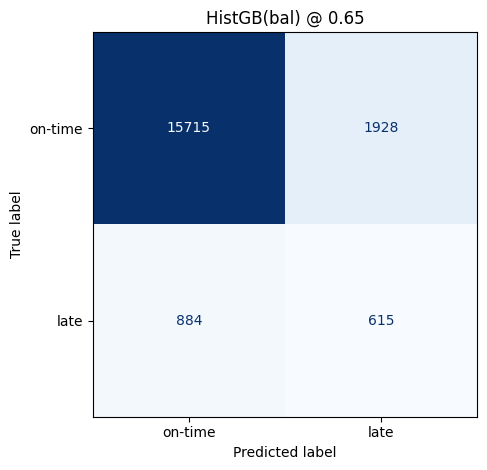

In [22]:
# --- 3. Everything side by side, tuned threshold, vs the original baseline ---
summary = (pd.DataFrame([
        score_at(l, _best_threshold(y_class_train, CONFIGS[l]['proba_tr'], 'f1'), '@maxF1')
        for l in CONFIGS])
    .sort_values('f1_late', ascending=False).reset_index(drop=True))

base = (CONFIGS['LogReg(bal)']['proba_te'] >= 0.5).astype(int)
print('BASELINE  LogReg(bal) @0.50 :  recall_late=%.3f  precision_late=%.3f  f1_late=%.3f'
      % (recall_score(y_class_test, base), precision_score(y_class_test, base),
         f1_score(y_class_test, base)))
print()
print(summary.to_string(index=False))

best_label = summary.iloc[0]['config'].rsplit(' ', 1)[0]
t = _best_threshold(y_class_train, CONFIGS[best_label]['proba_tr'], 'f1')
pred = (CONFIGS[best_label]['proba_te'] >= t).astype(int)
print(f'\n=== best by F1(late): {best_label} @ threshold {t:.3f} ===')
print(classification_report(y_class_test, pred, target_names=['on-time', 'late'], digits=3))
ConfusionMatrixDisplay(confusion_matrix(y_class_test, pred),
                       display_labels=['on-time', 'late']).plot(cmap='Blues', colorbar=False)
plt.title(f'{best_label} @ {t:.2f}'); plt.tight_layout(); plt.show()

---

## Framing A (Regression): Delivery Lead Time in Days

Same features, same split — just a continuous target this time.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

reg_results = {}
for name, model in reg_models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_reg_train)
    pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_reg_test, pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, pred))
    r2 = r2_score(y_reg_test, pred)
    reg_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(name, '| MAE:', round(mae, 2), '| RMSE:', round(rmse, 2), '| R2:', round(r2, 3))

Linear Regression | MAE: 4.83 | RMSE: 6.93 | R2: 0.329
Random Forest | MAE: 4.62 | RMSE: 6.74 | R2: 0.365
Gradient Boosting | MAE: 4.68 | RMSE: 6.79 | R2: 0.357


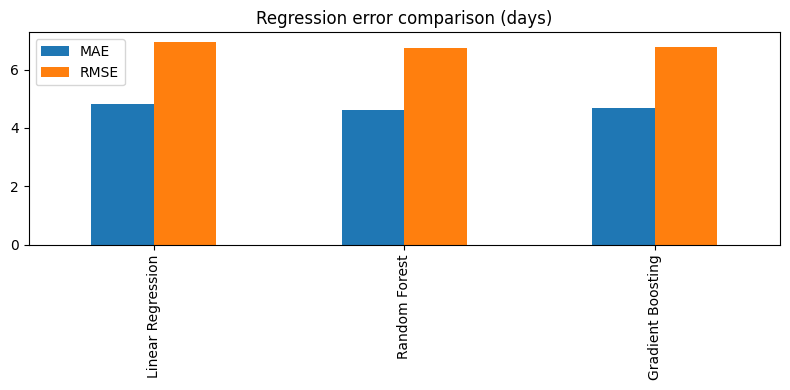

In [24]:
pd.DataFrame(reg_results).T[['MAE', 'RMSE']].plot(kind='bar', figsize=(8, 4), title='Regression error comparison (days)')
plt.tight_layout()
plt.show()

## 4. Notes for Phase 2

- Worth checking feature importances (tree models) to confirm `distance_km` and `total_freight` are pulling their weight, and whether `category`/state one-hot columns add noise given their cardinality.
- Both framings share one feature pipeline (`preprocessor`) — reinforces the "one problem, two outputs" framing for the writeup.

### Feature ideas to explore

- **Estimate tightness.** No model currently sees Olist's own estimate, yet `is_late` is defined against it. Try the raw promised window (`order_estimated_delivery_date − order_purchase_timestamp`), and — likely more informative — its **slack vs. the route norm**: `promised_window − typical_delivery_days(route)`, where the norm is a train-only median by state-pair or distance bucket. A tight or negative slack could flag late risk. Keep the baseline leakage-safe (train-only or past-orders rolling stat); zip-prefix pairs are too sparse for the norm, so use state-pairs or distance deciles.
- **Fulfilment lags.** `purchase → order_approved_at`, and `order_approved_at → order_delivered_carrier_date` — the latter is only known after dispatch, so it suits a post-dispatch model, not a checkout-time one.
- **Purchase timing.** weekday, hour, days to the nearest Brazilian public holiday.
- **Seller / route history.** rolling late-rate and mean review score per seller and per state-pair (train-only).
- **Interactions.** distance × weight, freight ÷ price.